# Análisis Exploratorio de Datos
## Road Safety UK - STATS19 (Department for Transport)

**Objetivo:** Analizar hipótesis sobre la física, patrones estacionales y geografía de los accidentes el Reino Unido.

### Hipótesis a evaluar:
1. El tipo de impacto influye en la tasa de mortalidad de los accidentes.
2. La distribución de accidentes a lo largo del año sigue un patrón repetitivo para todos los años.
3. Los accidentes fatales se concentran en determinadas localidades.

## Configuración

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.append(str(Path().resolve().parent))

# Configuración
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,8)
# Ruta a los datos procesados
DATA_PATH = Path('../data/processed')
REPORT_PATH = Path('../report')

## Carga de Datos Procesados

In [108]:
collision = pd.read_parquet(DATA_PATH / 'uk_collision_cln.parquet')
casualty = pd.read_parquet(DATA_PATH / 'uk_casualty_cln.parquet')
vehicle = pd.read_parquet(DATA_PATH / 'uk_vehicle_cln.parquet')

print(f"Collision: {collision.shape}")
print(f"Casualty: {casualty.shape}")
print(f"Vehicle: {vehicle.shape}")

Collision: (503395, 22)
Casualty: (640522, 8)
Vehicle: (920692, 9)


## Preparación General (Merges comunes)

In [109]:
# Merge Collision + Casualty
df_cas = collision.merge(casualty, on='collision_index', how='left')

## Análisis por Hipótesis

### Hipótesis 1: El tipo de impacto influye en la tasa de mortalidad

Voy a unir los datasets de colisión y vehiculo para que tengamos la informacion conjunta

In [110]:
df_coll_veh = collision.merge(vehicle, on='collision_index', how='inner')
df_coll_veh.head()

,collision_index,date_time,longitude,latitude,police_force,collision_severity,number_of_vehicles,number_of_casualties,day_of_week,local_authority_ons_district,local_authority_highway,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,light_conditions,weather_conditions,road_surface_conditions,urban_or_rural_area,vehicle_type,vehicle_manoeuvre,vehicle_leaving_carriageway,hit_object_off_carriageway,first_point_of_impact,sex_of_driver,age_of_driver,age_band_of_driver
0,2021170H10421,2021-05-22 22:44:00,-1.270905,54.689833,17,3,2,2,7,E06000001,E06000001,6,0,6,60,0,-1,0,6,1,1,2,9,19,0,0,0,3,-1,-1
1,2021170H10421,2021-05-22 22:44:00,-1.270905,54.689833,17,3,2,2,7,E06000001,E06000001,6,0,6,60,0,-1,0,6,1,1,2,9,19,1,4,1,2,30,6
2,2021170H11231,2021-10-20 15:50:00,-1.218333,54.690592,17,3,2,1,4,E06000001,E06000001,4,1277,6,30,16,2,5,1,1,1,1,9,7,0,0,1,1,40,7
3,2021170H11231,2021-10-20 15:50:00,-1.218333,54.690592,17,3,2,1,4,E06000001,E06000001,4,1277,6,30,16,2,5,1,1,1,1,8,7,0,0,2,1,50,8
4,2020170M11750,2020-12-01 18:00:00,-1.232884,54.570397,17,3,2,1,3,E06000002,E06000002,6,0,6,20,16,4,6,4,1,1,1,1,19,0,0,1,1,25,5


Voy a reducir en numero de variables para.

In [111]:
hp_impact = df_coll_veh[['first_point_of_impact','collision_severity', 'vehicle_type']]
hp_impact.head()

,first_point_of_impact,collision_severity,vehicle_type
0,0,3,9
1,1,3,9
2,1,3,9
3,2,3,8
4,1,3,1


Reemplazamos las categorías numéricas con los valores de texto

In [112]:
from src.uk_data_mapper import create_data_map

collision_value_map = create_data_map('collision', collision.columns)
casualty_value_map = create_data_map('casualty', casualty.columns)
vehicle_value_map = create_data_map('vehicle', vehicle.columns)

Voy a recategorizar los impactos laterales como una sola categoria.

In [113]:
hp_impact = hp_impact.replace(collision_value_map).replace(vehicle_value_map)
hp_impact['first_point_of_impact'] = hp_impact['first_point_of_impact'].replace({'Offside':'Side','Nearside':'Side'})
hp_impact.head()

,first_point_of_impact,collision_severity,vehicle_type
0,Did not impact,Slight,Car
1,Front,Slight,Car
2,Front,Slight,Car
3,Back,Slight,Taxi/Private hire car
4,Front,Slight,Pedal cycle


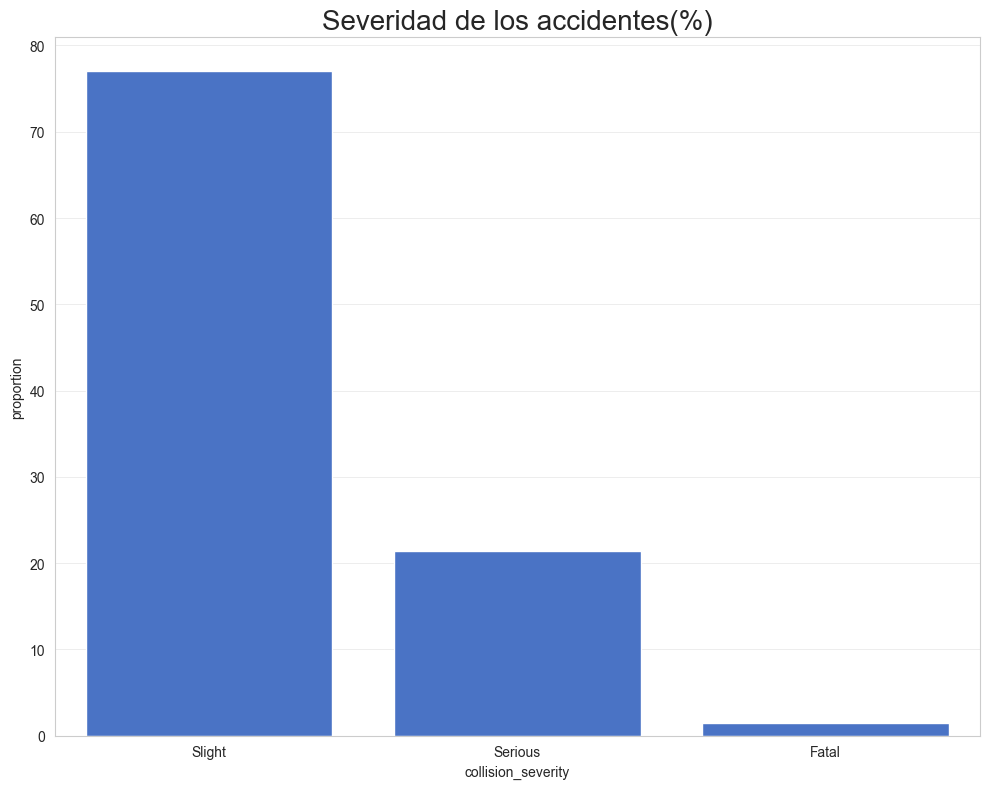

In [139]:
severity_bar = (hp_impact['collision_severity'].value_counts(normalize=True) * 100).reset_index()
sns.barplot(data=severity_bar, x='collision_severity', y='proportion')
plt.title(label='Severidad de los accidentes(%)', fontsize=20)
plt.tight_layout()
plt.savefig(REPORT_PATH / 'severity_bar.png', bbox_inches='tight')

<Axes: xlabel='first_point_of_impact', ylabel='proportion'>

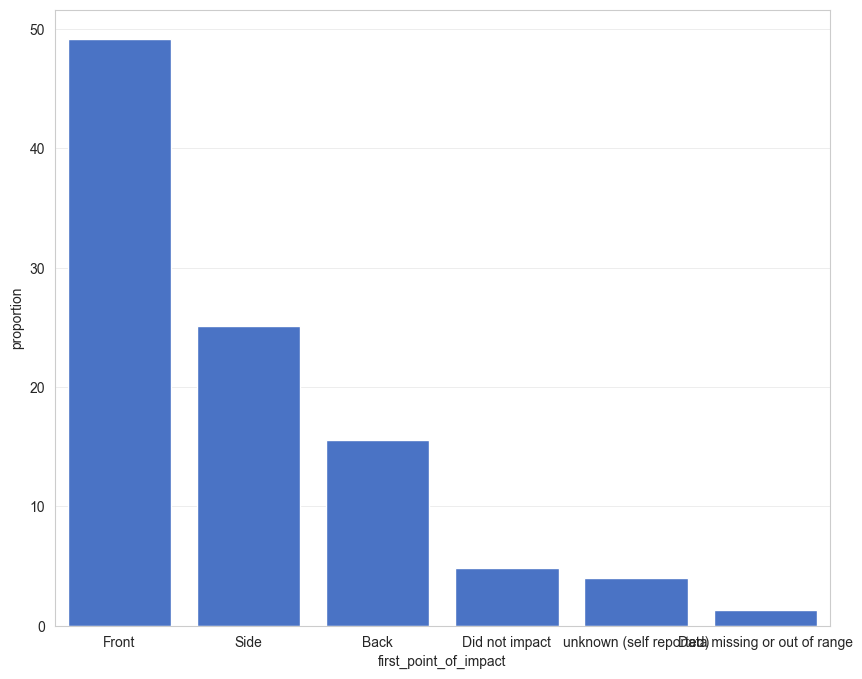

In [115]:
impact_bar = (hp_impact['first_point_of_impact'].value_counts(normalize=True) * 100).reset_index()
sns.barplot(data=impact_bar, x='first_point_of_impact', y='proportion')

 Voy a quedarme solo con los valores que no sean faltantes

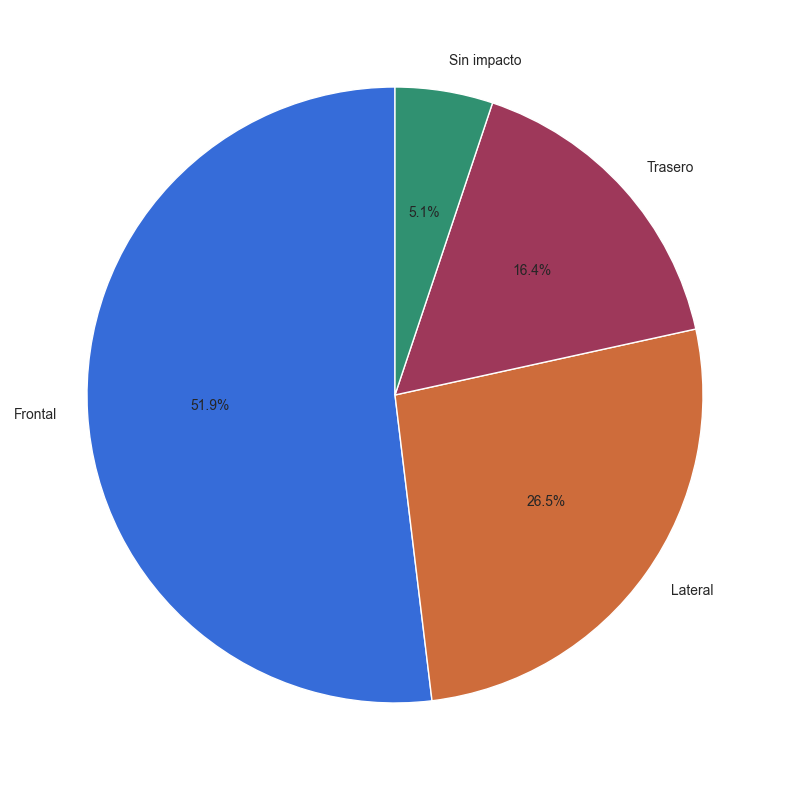

In [143]:
hp_impact = hp_impact[hp_impact['first_point_of_impact'].isin(['Front','Back','Side','Did not impact'])]
impact_bar = (hp_impact['first_point_of_impact'].value_counts(normalize=True) * 100).reset_index()
impact_bar = impact_bar.replace({'Front':'Frontal','Back':'Trasero','Side':'Lateral','Did not impact':'Sin impacto'})
#sns.barplot(data=impact_bar, x='first_point_of_impact', y='proportion')
plt.pie(
    impact_bar['proportion'],
    labels=impact_bar['first_point_of_impact'],
    autopct="%1.1f%%",
    startangle=90
)
plt.tight_layout()
plt.savefig(REPORT_PATH / 'impact_bar.png', bbox_inches='tight')

In [140]:
impact_bar

,first_point_of_impact,proportion
0,Frontal,51.917778
1,Lateral,26.519791
2,Trasero,16.432838
3,Sin impacto,5.129593


Calculo la tasa de fatalidad para cada tipo de choque. Este indica el el porcentaje de que una colisión sea fatal cuando ya ha ocurrido.

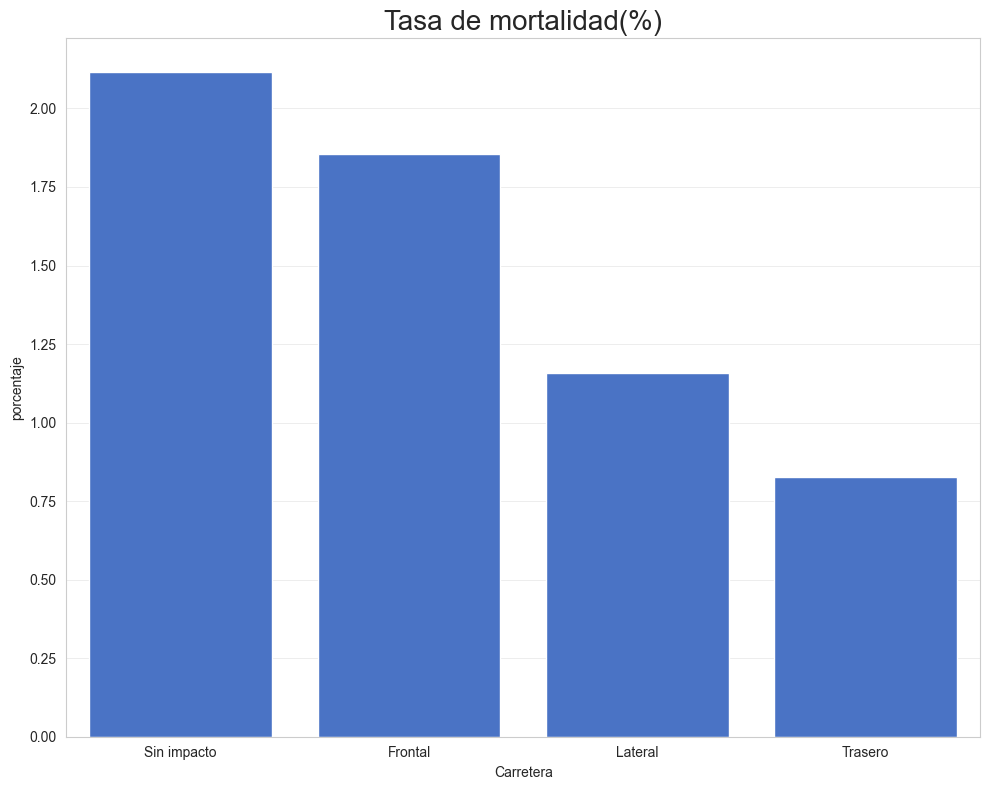

In [117]:
by_type_total = hp_impact.groupby('first_point_of_impact').size()
by_type_fatal_total = hp_impact[hp_impact['collision_severity'].isin(['Fatal'])].groupby('first_point_of_impact').size()
fatal_rate = (by_type_fatal_total / by_type_total * 100).reset_index(name='proportion')
fatal_rate = fatal_rate.sort_values(by='proportion', ascending=False)
fatal_rate = fatal_rate.replace({'Front':'Frontal','Back':'Trasero','Side':'Lateral','Did not impact':'Sin impacto'})
sns.barplot(data=fatal_rate, x='first_point_of_impact', y='proportion')
plt.title(label='Tasa de mortalidad(%)', fontsize=20)
plt.xlabel('Carretera')
plt.ylabel('porcentaje')
plt.tight_layout()
plt.savefig(REPORT_PATH / 'fatal_rate_impact_bar.png', bbox_inches='tight')

**Observaciones:** \
A pesar de que los accidentes que no tienen impactos directos con otros vehículos/peatónes/objetos representan un 5% de los accidentes totales, tienen la mayor tasa de mortalidad. Los accidentes calificados como 'Did not impact' son aquellos en los que el vehículo frena o esquiva un vehiculo/peatón/objeto pero no hay impacto. Esto se indica en la pagina 55 del siguiente [documento](https://assets.publishing.service.gov.uk/government/uploads/system/uploads/attachment_data/file/995424/stats20-2005.pdf).

Voy a analizar este caso concreto más en profundidad.

In [118]:
hp_no_impact = df_coll_veh.loc[(df_coll_veh['vehicle_type'] != -1),['first_point_of_impact', 'collision_severity', 'vehicle_leaving_carriageway', 'vehicle_type', 'vehicle_manoeuvre']]
hp_no_impact = hp_no_impact.replace(collision_value_map).replace(vehicle_value_map)

#seleccionamos accidentes fatales de que no hayan tenido impacto directo
hp_no_impact = hp_no_impact[(hp_no_impact['first_point_of_impact'].isin(['Did not impact'])) & (hp_no_impact['collision_severity'].isin(['Fatal']))][['vehicle_leaving_carriageway', 'vehicle_type', 'vehicle_manoeuvre']]

<Axes: xlabel='count', ylabel='vehicle_type'>

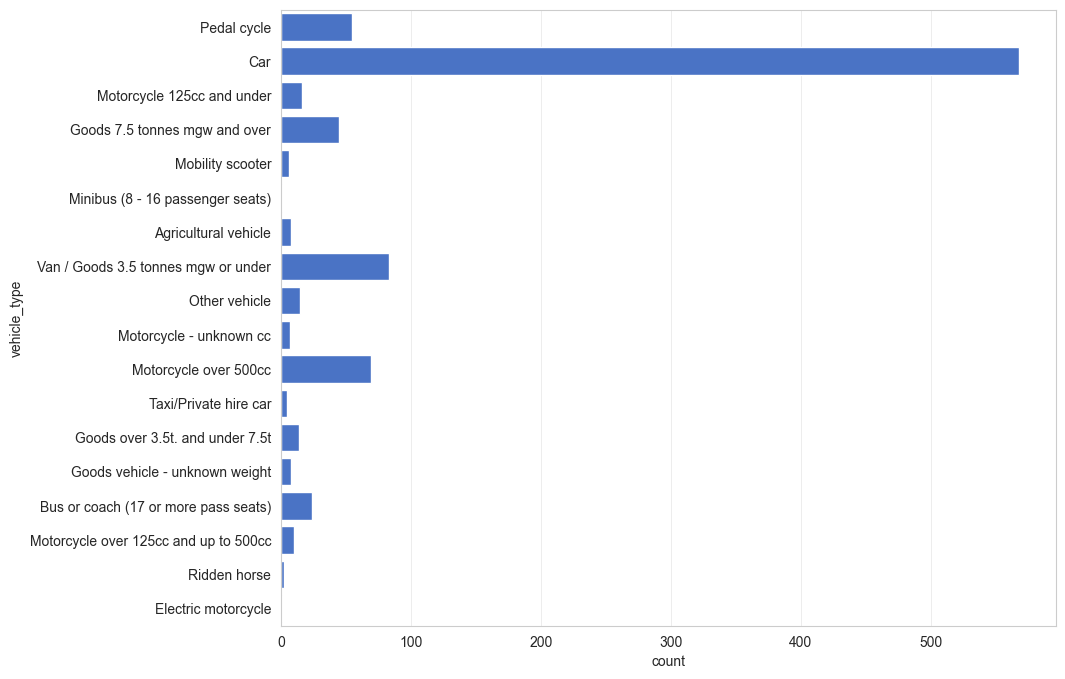

In [119]:
sns.countplot(data=hp_no_impact['vehicle_type'])

Voy a recategorizar los tipos de vehiculos de manera mas general en una nueva variable para ver las proporciones de cada uno

In [120]:
condiciones = [
    hp_no_impact['vehicle_type'].str.lower().str.contains('car'),
    hp_no_impact['vehicle_type'].str.lower().str.contains('motorcycle'),
    hp_no_impact['vehicle_type'].str.lower().str.contains('pedal'),
    hp_no_impact['vehicle_type'].str.lower().str.contains('goods'),
    hp_no_impact['vehicle_type'].str.lower().str.contains('bus'),
]

valores = ['Coche', 'Moto', 'Bici', 'Mercancías', 'Bus']

hp_no_impact['vehicle_family'] = np.select(condiciones, valores, default='Otros')
hp_no_impact['vehicle_family'].value_counts().index

Index(['Coche', 'Mercancías', 'Moto', 'Bici', 'Otros', 'Bus'], dtype='str', name='vehicle_family')

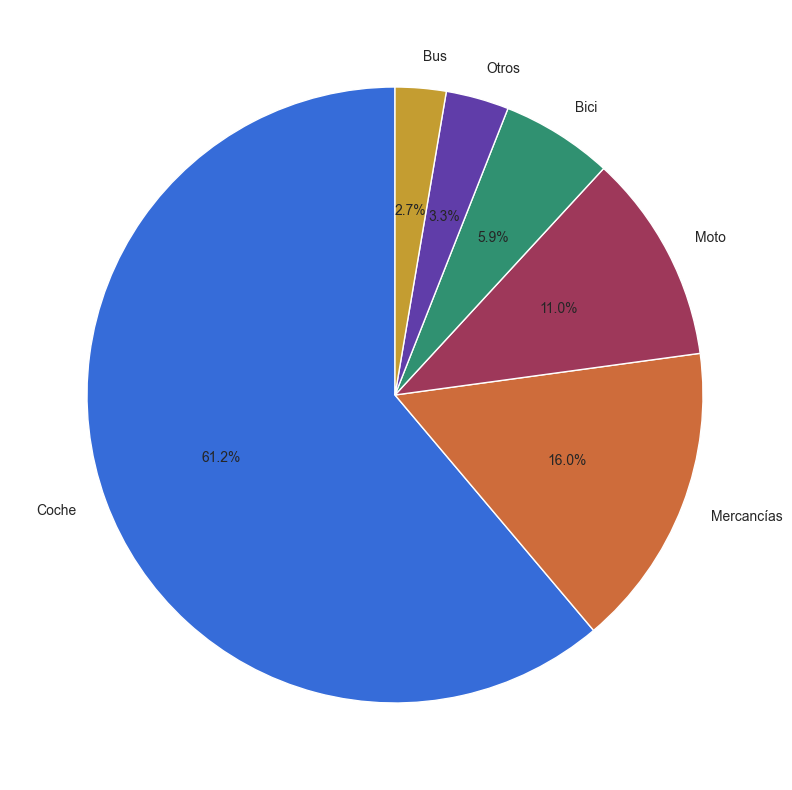

In [121]:
plt.pie(
    hp_no_impact['vehicle_family'].value_counts(),
    labels=['Coche', 'Mercancías', 'Moto', 'Bici', 'Otros', 'Bus'],
    autopct="%1.1f%%",
    startangle=90
)
plt.tight_layout()
#plt.savefig(REPORT_PATH / 'severity_bar.png', bbox_inches='tight')

### Hipótesis 2: Patrón mensual repetitivo de accidentes a lo largo del todos los años

In [122]:
import locale
locale.setlocale(locale.LC_TIME, "es_ES.UTF-8")

hp_yearly_pattern = collision[['date_time']]
hp_yearly_pattern = hp_yearly_pattern.sort_values(by='date_time')

hp_yearly_pattern['year'] = hp_yearly_pattern['date_time'].dt.year
hp_yearly_pattern['month'] = hp_yearly_pattern['date_time'].dt.strftime("%B").str.title()
orden_meses = [
    "Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
    "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"
]
hp_yearly_pattern["month"] = pd.Categorical(hp_yearly_pattern["month"], categories=orden_meses, ordered=True)
hp_yearly_pattern['week'] = hp_yearly_pattern['date_time'].dt.isocalendar().week
hp_yearly_pattern['day'] = hp_yearly_pattern['date_time'].dt.day

hp_yearly_pattern

,date_time,year,month,week,day
290264,2020-01-01 00:01:00,2020,Enero,1,1
481181,2020-01-01 00:05:00,2020,Enero,1,1
486667,2020-01-01 00:05:00,2020,Enero,1,1
341665,2020-01-01 00:15:00,2020,Enero,1,1
262440,2020-01-01 00:15:00,2020,Enero,1,1
...,...,...,...,...,...
307632,2024-12-31 23:10:00,2024,Diciembre,1,31
65660,2024-12-31 23:10:00,2024,Diciembre,1,31
303399,2024-12-31 23:16:00,2024,Diciembre,1,31
9928,2024-12-31 23:20:00,2024,Diciembre,1,31


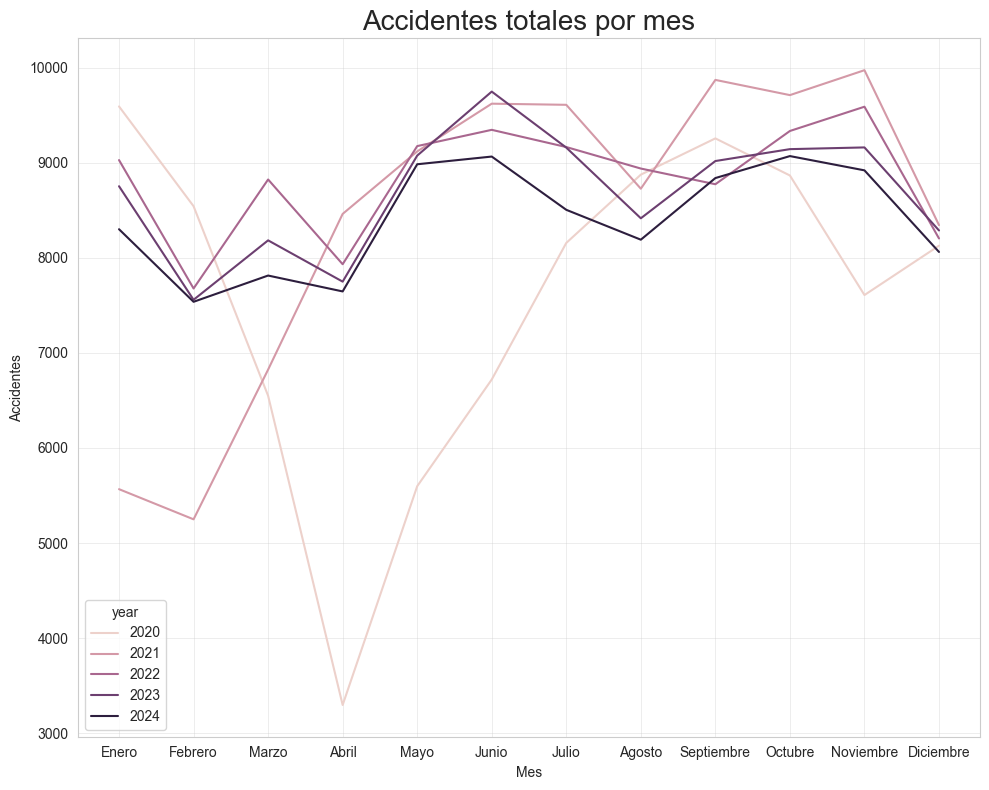

In [123]:
by_month = hp_yearly_pattern.groupby(['year','month']).size().reset_index(name='count')
sns.lineplot(data=by_month, x='month', y='count', hue='year')
plt.title(label='Accidentes totales por mes', fontsize=20)
plt.xlabel('Mes')
plt.ylabel('Accidentes')
plt.tight_layout()
plt.savefig(REPORT_PATH / 'by_mont_line.png', bbox_inches='tight')

Podemos observar que los años 2022, 2023, 2024 hay un patron muy similar en cuanto a las subidas y bajadas de accidentes por mes.
Es muy importante tener en cuenta que en los años 2020 y 2021 se produjo una pandemia mundial que llevo a los paises realizar confinamientos, reduciendo exageradamente la movilidad del trafico y los accidentes que ocurrieron en ese periodo de tiempo. En el caso de UK que es el pais que estamos analizando se produjeron 2 confinamientos, en marzo de 2020 y enero de 2021. Se ve reflejado en la grafica

In [124]:
pivot = by_month.pivot(index='month', columns='year', values='count')
pivot
# sns.countplot(data=pivot, x='year')

year,2020,2021,2022,2023,2024
month,,,,,
Enero,9591,5567,9027,8752,8300
Febrero,8542,5250,7677,7558,7537
Marzo,6549,6824,8823,8183,7813
Abril,3298,8461,7932,7749,7646
Mayo,5598,9118,9174,9074,8983
Junio,6720,9620,9345,9747,9064
Julio,8156,9608,9164,9158,8504
Agosto,8874,8726,8938,8415,8190
Septiembre,9255,9870,8773,9017,8838


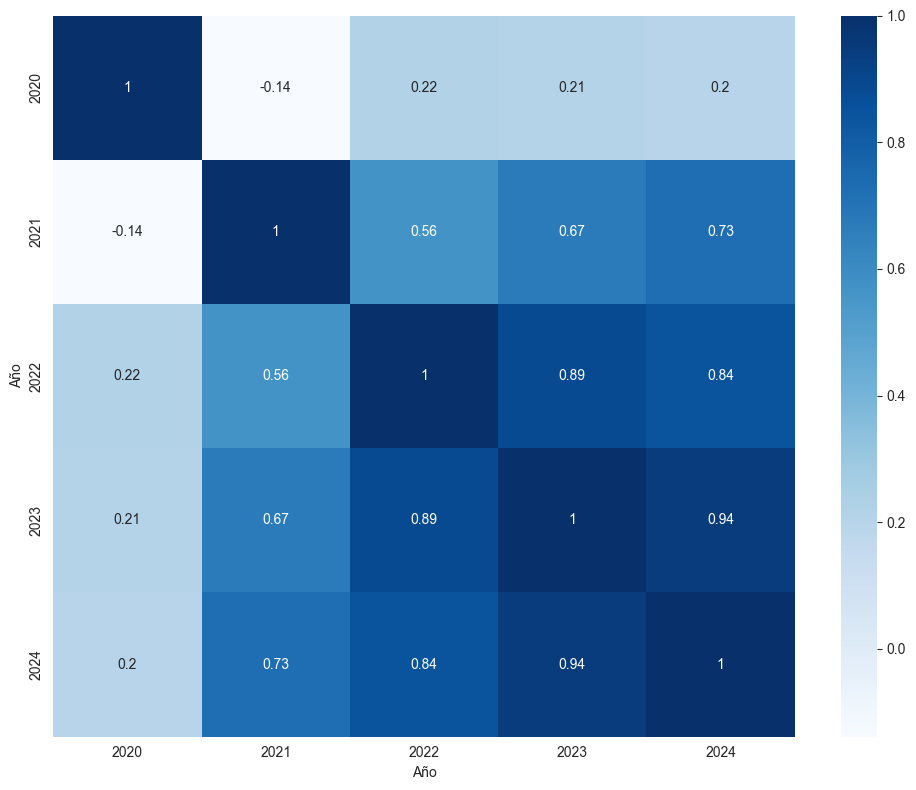

In [125]:
sns.heatmap(data=pivot.corr(), annot=True, cmap='Blues')
#plt.title(label='Accidentes totales por mes', fontsize=20)
plt.xlabel('Año')
plt.ylabel('Año')
plt.tight_layout()
plt.savefig(REPORT_PATH / 'by_year_heat.png', bbox_inches='tight')

Se ve claramente como al comparar la distribucion mensual de accidentes por año, se rompe la correlacion para el año 2020 ,que fue el año mas serio de la pandemia, y a medida que se fue estableciendo la normalidad tambien lo hacen el numero de accidentes mensuales, llegando a un coeficiente de correlación del 0.94 comparando 2023 y 2024.

### Hipótesis 3: Accidentes fatales concentrados en ciertas localidades

In [126]:
import folium as fol
from folium.plugins import HeatMap

In [144]:
hp_geo = collision.loc[collision['collision_severity'].isin([1]), ['latitude','longitude']]
coords = zip(hp_geo['latitude'], hp_geo['longitude'])
location = [hp_geo["latitude"].mean(), hp_geo["longitude"].mean()]
m = fol.Map(location=location, zoom_start=7, tiles="cartodb positron")
heat_data = coords
HeatMap(
    heat_data,
    radius=5,      # tamaño del punto
    blur=2,       # suavizado
    max_zoom=13,
    show=True,
    gradient={.4: "blue", .6: "cyan", .7: "lime", .8: "yellow", 1: "red"}
).add_to(m)
m.save(REPORT_PATH / 'heat_map_fatal.html')
m


La mayoría de los accidentes con consecuencias fatales se concentran geográficamente en las ciudades más pobladas del país. Una conclusión bastante logica, pero hay accidentes que están dispersos que pueden estar en la misma carretera, por lo tanto vamos a mirar esa casuística más detalladamente analizando las carreteras donde hayan ocurrido el mayor de accidentes fatales. Nos centraremos en carreteras generales(A) y autopistas(M), obviando las carreteras que no estén clasificadas.

In [128]:
hp_geo_2 = collision.loc[(collision['collision_severity'].isin([1])) & (collision['first_road_number']), ['first_road_class','first_road_number', 'latitude', 'longitude']]
hp_geo_2 = hp_geo_2.replace(collision_value_map).reset_index(drop=True)
road_count = hp_geo_2.groupby(['first_road_class','first_road_number']).size().reset_index(name='count')
road_count['first_road_class'] = road_count['first_road_class'].replace({'Motorway':'M'})
road_count['road_name'] = road_count['first_road_class'] + road_count['first_road_number'].astype(str)
road_count = road_count.drop(columns=['first_road_number', 'first_road_class'])[['road_name', 'count']]
top10 = road_count.sort_values(by='count', ascending=False).head()
top10

,road_name,count
2,A5,57
23,A47,52
838,M1,46
0,A1,40
20,A41,38


Estas son las 5 carreteras donde ha habido mas accidentes fatales.

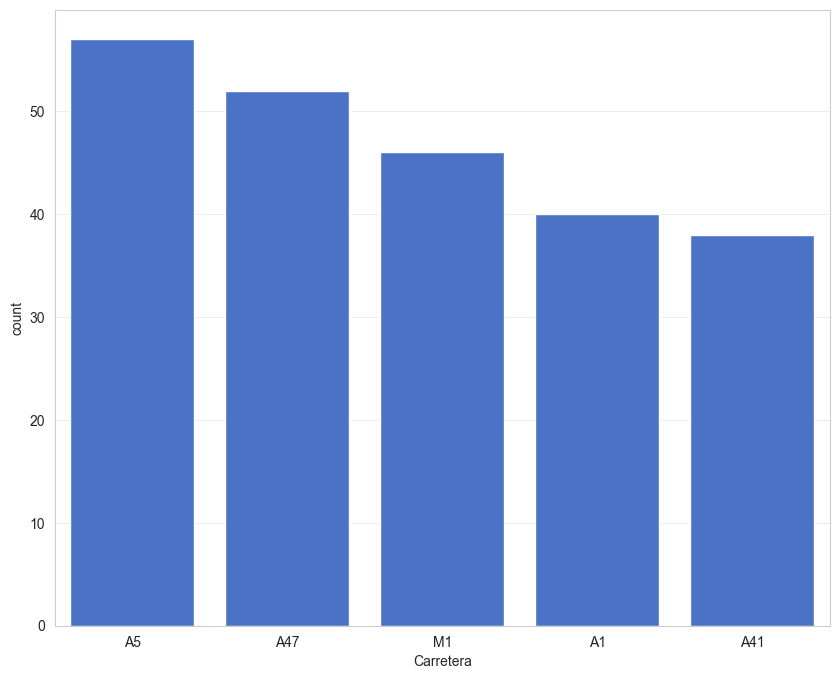

In [129]:
sns.barplot(data=top10, x='road_name', y='count')
#plt.title(label='5 carreteras con más accidentes fatales', fontsize=20)
plt.xlabel('Carretera')
plt.savefig(REPORT_PATH / 'top5.png', bbox_inches='tight')

In [130]:
hp_geo_2['first_road_class'] = hp_geo_2['first_road_class'].replace({'Motorway':'M'})
hp_geo_2['road_name'] = hp_geo_2['first_road_class'] + hp_geo_2['first_road_number'].astype(str)
hp_geo_2 = hp_geo_2.drop(columns=['first_road_number', 'first_road_class'])[['road_name', 'latitude', 'longitude']]
hp_geo_2

,road_name,latitude,longitude
0,A47,52.594809,-0.486782
1,A33,51.377552,-0.982039
2,M1,52.118020,-0.802540
3,A49,52.581852,-2.775182
4,A395,50.636544,-4.507333
...,...,...,...
2685,A191,55.023723,-1.481891
2686,A449,52.560750,-2.153400
2687,A6177,53.771224,-1.759879
2688,A2211,51.466689,-0.011289


Dibujamos en el mapa las localizaciones de los accidentes de las cinco carreteras con mayor número de accidentes fatales.

In [134]:
hp_geo_2 = hp_geo_2[hp_geo_2['road_name'].isin(top10['road_name'].unique().tolist())]
cat = top10['road_name'].unique().tolist()
color = [
    'red', 'blue', 'green', 'purple', 'orange', 'darkred',
]
color_map = dict(zip(cat, color))

m = fol.Map(location=[hp_geo_2['latitude'].mean(), hp_geo_2['longitude'].mean()], zoom_start=7, tiles="cartodb positron")
for _, row in hp_geo_2.iterrows():
    fol.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=color_map[row["road_name"]],
        fill=True,
        fill_opacity=0.7
    ).add_to(m)
legend_html = """
<div style="
    position: fixed;
    top: 50px;
    right: 50px;
    width: 130px;
    height: auto;
    background-color: white;
    border:2px solid grey;
    z-index:9999;
    font-size:14px;
    padding: 10px;
">
<b>Carretera</b><br>
"""

for categoria, color in color_map.items():
    legend_html += f"""
    <i style="background:{color};width:10px;height:10px;display:inline-block;"></i>
    {categoria}<br>
    """

legend_html += "</div>"

m.get_root().html.add_child(fol.Element(legend_html))

m.save(REPORT_PATH / 'heat_map_fatal_road.html')
m

## 5. Conclusiones Generales y Recomendaciones

**Resumen de hallazgos:**

- Hipótesis 1: Los accidentes que no colisionan directamente contra otro vehículo, objeto o peatón presentan la mayor tasa de mortalidad.
- Hipótesis 2: Tras la pandemia, los accidentes vuelven a mostrar un patrón claro y repetitivo.
- Hipótesis 3: Los accidentes fatales no solo se concentran en grandes ciudades, sino también en las carreteras mas transitadas que conectan grandes ciudades.


**Recomendaciones:**
- Fortalecer campañas de concienciación sobre el uso del cinturón, casco y respeto del limite de velocidad.
- Diseñar intervenciones focalizadas en los meses y periodos de mayor riesgo identificados por el análisis estacional.
- Focalizar la inversion recursos económicos en seguridad vial en territorios y tramos de carreteras donde se concentren los accidentes con peores consecuencias.